# Cobertura vacinal no Brasil (2015–2024): análise exploratória

**Avaliação G1 · Linguagem de Programação — Análise e Visualização de Dados com Python**

## 1. Introdução ao problema
A cobertura vacinal é a proporção do público-alvo que recebeu determinada vacina. Quando fica abaixo da meta
(80% ou 95%, conforme o registro), aumenta o risco de surtos de doenças que a vacinação evita.

**Perguntas que o projeto responde**
1. Qual é a cobertura média e quantos registros atingem a meta?
2. A cobertura mudou ao longo de 2015–2024?
3. Há diferenças relevantes entre regiões, vacinas e públicos-alvo?
4. O número de campanhas de vacinação acompanha a cobertura?
5. Onde estão os registros em nível crítico?

## 2. Explicação da base de dados
Arquivo `dados/simulacao_cobertura_vacinal_brasil.csv`: **dados simulados** (não são números oficiais), com um registro
por mês × município × vacina.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Período do registro (1º dia do mês) |
| `regiao`, `uf`, `municipio` | Localização |
| `vacina`, `publico_alvo` | Vacina aplicada e grupo atendido |
| `doses_aplicadas`, `populacao_alvo` | Doses aplicadas e tamanho do público-alvo |
| `cobertura_percentual` | Cobertura do registro (0–100) |
| `meta_percentual` | Meta de cobertura: 80 ou 95 |
| `campanhas` | Número de campanhas no mês |
| `nivel_alerta` | Crítico, Atenção ou Adequado |

## 3. Leitura dos dados

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
COR, COR_ALERTA = "#0E7C7B", {"Crítico": "#C2410C", "Atenção": "#E0A100", "Adequado": "#0E7C7B"}
PASTA_IMG = Path("../imagens"); PASTA_IMG.mkdir(exist_ok=True)
def salvar(nome): plt.savefig(PASTA_IMG / f"{nome}.png", dpi=130, bbox_inches="tight")

df = pd.read_csv("../dados/simulacao_cobertura_vacinal_brasil.csv", encoding="utf-8-sig")
print(df.shape)
df.head()

(4440, 14)


,ano,mes,data,regiao,uf,municipio,vacina,doses_aplicadas,publico_alvo,cobertura_percentual,meta_percentual,populacao_alvo,campanhas,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,Poliomielite,292274,Adultos,58.72,80,497714,0,Crítico
1,2015,1,2015-01-01,Norte,PA,Belém,BCG,181341,Adultos,81.73,80,221885,0,Adequado
2,2015,1,2015-01-01,Norte,PA,Santarém,Influenza,46148,Crianças,69.03,80,66849,3,Atenção
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Hepatite B,22357,Idosos,75.64,95,29558,0,Crítico
4,2015,1,2015-01-01,Norte,TO,Palmas,COVID-19,393777,Gestantes,86.57,95,454876,4,Atenção


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ano                   4440 non-null   int64  
 1   mes                   4440 non-null   int64  
 2   data                  4440 non-null   str    
 3   regiao                4440 non-null   str    
 4   uf                    4440 non-null   str    
 5   municipio             4440 non-null   str    
 6   vacina                4440 non-null   str    
 7   doses_aplicadas       4440 non-null   int64  
 8   publico_alvo          4440 non-null   str    
 9   cobertura_percentual  4440 non-null   float64
 10  meta_percentual       4440 non-null   int64  
 11  populacao_alvo        4440 non-null   int64  
 12  campanhas             4440 non-null   int64  
 13  nivel_alerta          4440 non-null   str    
dtypes: float64(1), int64(6), str(7)
memory usage: 729.8 KB


## 4. Limpeza e preparação

In [3]:
print("Valores ausentes:", int(df.isna().sum().sum()))
print("Linhas duplicadas:", df.duplicated().sum())
print("Chaves repetidas (data, município, vacina):", df.duplicated(["data", "municipio", "vacina"]).sum())
print("Cobertura fora de 0-100:", (~df.cobertura_percentual.between(0, 100)).sum())
print("Doses maiores que a população-alvo:", (df.doses_aplicadas > df.populacao_alvo).sum())
print("Registros com cobertura exatamente 100:", (df.cobertura_percentual == 100).sum())

# Cobertura informada x doses/população: confere se o campo é coerente
recalculada = df.doses_aplicadas / df.populacao_alvo * 100
print("Maior diferença |informada - recalculada|:", (df.cobertura_percentual - recalculada).abs().max().round(4))

Valores ausentes: 0
Linhas duplicadas: 0
Chaves repetidas (data, município, vacina): 0
Cobertura fora de 0-100: 0
Doses maiores que a população-alvo: 0
Registros com cobertura exatamente 100: 278
Maior diferença |informada - recalculada|: 0.0114


**O que encontramos.** A base está limpa: sem ausentes, sem duplicatas e sem valores impossíveis. Dois pontos merecem atenção:

- A `cobertura_percentual` é praticamente igual a `doses_aplicadas / populacao_alvo × 100` (diferença máxima de 0,01 p.p.). Ou seja,
  ela é **derivada** das doses e da população, e não uma medida independente.
- 278 registros têm cobertura de exatamente 100%, o que indica um **teto** aplicado na simulação.

Tratamentos aplicados: remoção de espaços nos textos, conversão de `data` para datetime, `clip` da cobertura em 0–100 e remoção de duplicatas
(nenhuma encontrada).

In [4]:
for c in ["regiao", "uf", "municipio", "vacina", "publico_alvo", "nivel_alerta"]:
    df[c] = df[c].str.strip()
df["data"] = pd.to_datetime(df["data"])
df["cobertura_percentual"] = df["cobertura_percentual"].clip(0, 100)
df = df.drop_duplicates()
df.dtypes

ano                              int64
mes                              int64
data                    datetime64[us]
regiao                             str
uf                                 str
municipio                          str
vacina                             str
doses_aplicadas                  int64
publico_alvo                       str
cobertura_percentual           float64
meta_percentual                  int64
populacao_alvo                   int64
campanhas                        int64
nivel_alerta                       str
dtype: object

## 5. Engenharia de atributos

In [5]:
df["periodo"] = df["data"].dt.to_period("M").dt.to_timestamp()
df["trimestre"] = df["data"].dt.quarter
df["gap_meta"] = df["cobertura_percentual"] - df["meta_percentual"]          # distância da meta, em p.p.
df["atingiu_meta"] = df["gap_meta"] >= 0
df["grupo_campanhas"] = pd.cut(df["campanhas"], [-1, 0, 1, 2, np.inf], labels=["0", "1", "2", "3 ou mais"]).astype(str)

# Como o nivel_alerta foi definido? Verificamos a regra pela distância da meta:
df.groupby("nivel_alerta")["gap_meta"].agg(["min", "max", "count"]).round(2)

,min,max,count
nivel_alerta,,,
Adequado,0.00,20.00,1543
Atenção,-14.99,-0.02,1936
Crítico,-48.03,-15.00,961


O `nivel_alerta` segue uma regra clara sobre a distância da meta: **Adequado** (cobertura ≥ meta), **Atenção** (até 15 p.p. abaixo)
e **Crítico** (15 p.p. ou mais abaixo). Criamos `gap_meta` e `atingiu_meta` para usar essa mesma lógica nos cálculos.

## 6. KPIs

In [6]:
def cobertura_ponderada(d): return d.doses_aplicadas.sum() / d.populacao_alvo.sum() * 100

kpis = pd.Series({
    "Registros": len(df),
    "Doses aplicadas": df.doses_aplicadas.sum(),
    "Cobertura ponderada (%)": cobertura_ponderada(df),
    "Cobertura mediana (%)": df.cobertura_percentual.median(),
    "Registros que atingiram a meta (%)": df.atingiu_meta.mean() * 100,
    "Registros em nível crítico (%)": (df.nivel_alerta == "Crítico").mean() * 100,
    "Distância média da meta (p.p.)": df.gap_meta.mean(),
    "Registros com meta de 95% (%)": (df.meta_percentual == 95).mean() * 100,
}).round(2)
kpis

Registros                             4.440000e+03
Doses aplicadas                       9.509877e+08
Cobertura ponderada (%)               8.400000e+01
Cobertura mediana (%)                 8.431000e+01
Registros que atingiram a meta (%)    3.475000e+01
Registros em nível crítico (%)        2.164000e+01
Distância média da meta (p.p.)       -5.120000e+00
Registros com meta de 95% (%)         6.081000e+01
dtype: float64

**Leitura.** A cobertura ponderada é de **84,0%**, mas só **34,8%** dos registros atingem a meta, e **21,6%** estão em nível crítico.
A distância média da meta é de **−5,1 p.p.** Parte disso vem da própria meta: **60,8%** dos registros têm meta de 95%, que é mais exigente.

## 7. Análise exploratória e gráficos

### 7.1 Distribuição da cobertura

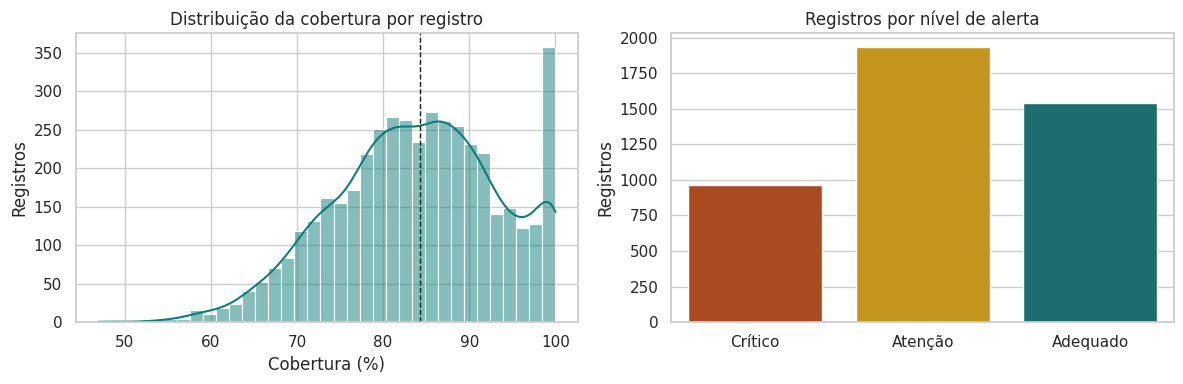

count    4440.00
mean       84.00
std         9.59
min        46.97
25%        77.53
50%        84.31
75%        90.94
max       100.00
Name: cobertura_percentual, dtype: float64

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.cobertura_percentual, bins=35, kde=True, color=COR, ax=ax[0])
ax[0].axvline(df.cobertura_percentual.median(), color="k", ls="--", lw=1)
ax[0].set(title="Distribuição da cobertura por registro", xlabel="Cobertura (%)", ylabel="Registros")
sns.countplot(data=df, x="nivel_alerta", order=["Crítico", "Atenção", "Adequado"], palette=COR_ALERTA, ax=ax[1])
ax[1].set(title="Registros por nível de alerta", xlabel="", ylabel="Registros")
plt.tight_layout(); salvar("01_distribuicao"); plt.show()
df.cobertura_percentual.describe().round(2)

**Interpretação.** A distribuição é unimodal, com centro em torno de 84% e uma cauda para a esquerda (assimetria ≈ −0,25). Metade dos registros fica entre
77,5% e 90,9%, e o acúmulo no valor 100 vem do teto da simulação. O nível **Atenção** é o mais frequente (43,6%), seguido de **Adequado** (34,8%) e **Crítico** (21,6%).

### 7.2 Evolução temporal

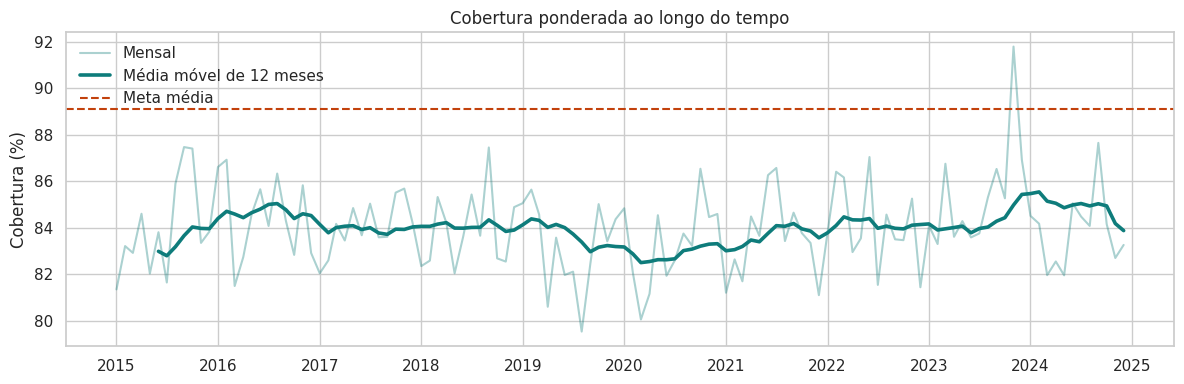

Tendência linear: +0.04 p.p. por ano


ano,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
cobertura,83.82,84.58,84.07,83.86,83.23,83.34,83.61,84.18,85.50,83.86
criticos_%,20.72,21.40,19.59,22.07,22.30,25.00,21.17,21.17,18.69,24.32


In [8]:
mensal = df.groupby("periodo").apply(lambda g: cobertura_ponderada(g)).rename("cobertura").to_frame()
mensal["media_12m"] = mensal.cobertura.rolling(12, min_periods=6).mean()
anual = df.groupby("ano").apply(lambda g: pd.Series({"cobertura": cobertura_ponderada(g),
        "criticos_%": (g.nivel_alerta == "Crítico").mean() * 100})).round(2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mensal.index, mensal.cobertura, color=COR, alpha=.35, label="Mensal")
ax.plot(mensal.index, mensal.media_12m, color=COR, lw=2.6, label="Média móvel de 12 meses")
ax.axhline(df.meta_percentual.mean(), color="#C2410C", ls="--", label="Meta média")
ax.set(title="Cobertura ponderada ao longo do tempo", ylabel="Cobertura (%)", xlabel="")
ax.legend(frameon=False); plt.tight_layout(); salvar("02_serie_temporal"); plt.show()

tendencia = np.polyfit(np.arange(len(mensal)), mensal.cobertura, 1)[0] * 12
print(f"Tendência linear: {tendencia:+.2f} p.p. por ano")
anual.T

**Interpretação.** Não há tendência: a inclinação linear é de apenas **+0,04 p.p. por ano**. A cobertura anual oscila entre **83,2% (2019)** e **85,5% (2023)**,
e a pior fatia anual para o nível crítico foi 2020 (25%) e 2024 (24%). A oscilação mensal é maior que a diferença entre anos: a cobertura mensal chegou a 79,5% em agosto de 2019
e a 91,8% em novembro de 2023. Como a base é simulada, esses movimentos refletem o gerador de dados e não eventos reais como a pandemia.

### 7.3 Comparativos: vacina, região e público-alvo

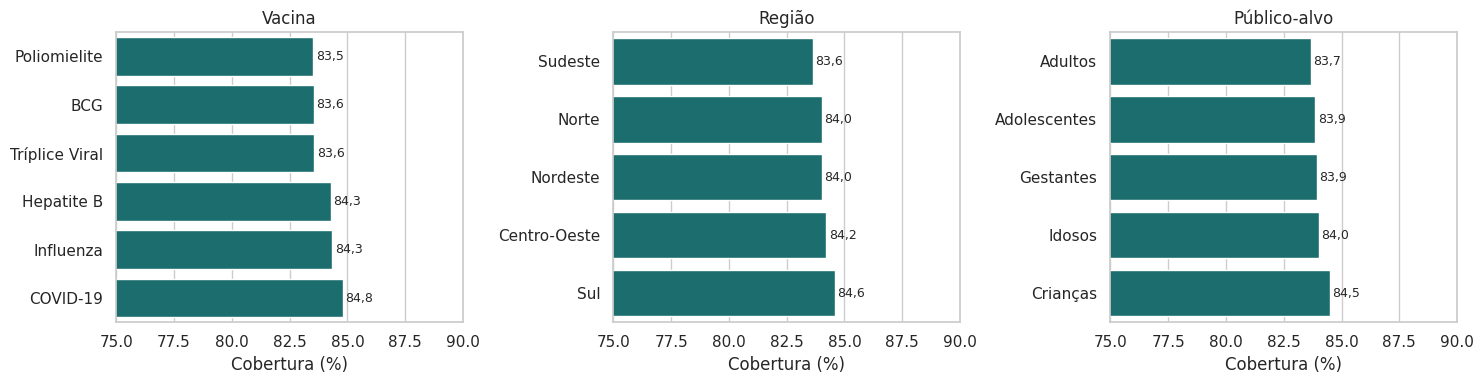

,cobertura,meta_atingida_%,criticos_%,registros
vacina,,,,
Poliomielite,83.53,33.63,23.66,782.0
BCG,83.56,34.08,20.66,760.0
Tríplice Viral,83.57,32.82,23.00,713.0
Hepatite B,84.28,36.62,20.39,721.0
Influenza,84.35,36.41,21.59,769.0
COVID-19,84.79,34.96,20.43,695.0


In [9]:
def resumo(por):
    g = df.groupby(por).apply(lambda g: pd.Series({
        "cobertura": cobertura_ponderada(g), "meta_atingida_%": g.atingiu_meta.mean() * 100,
        "criticos_%": (g.nivel_alerta == "Crítico").mean() * 100, "registros": len(g)}))
    return g.round(2).sort_values("cobertura")

por_vacina, por_regiao, por_publico = resumo("vacina"), resumo("regiao"), resumo("publico_alvo")

fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for a, t, titulo in zip(ax, [por_vacina, por_regiao, por_publico], ["Vacina", "Região", "Público-alvo"]):
    sns.barplot(x=t.cobertura, y=t.index, color=COR, ax=a)
    a.set(title=titulo, xlabel="Cobertura (%)", ylabel="", xlim=(75, 90))
    for i, v in enumerate(t.cobertura): a.text(v + .1, i, f"{v:.1f}".replace(".", ","), va="center", fontsize=9)
plt.tight_layout(); salvar("03_comparativos"); plt.show()
por_vacina

In [10]:
por_regiao

,cobertura,meta_atingida_%,criticos_%,registros
regiao,,,,
Sudeste,83.62,33.01,21.67,1560.0
Norte,84.01,34.33,21.33,600.0
Nordeste,84.02,35.52,23.44,960.0
Centro-Oeste,84.22,37.50,22.67,600.0
Sul,84.60,35.56,18.61,720.0


**Interpretação.** As diferenças são pequenas. Entre vacinas, vai de **83,5% (Poliomielite)** a **84,8% (COVID-19)**; entre regiões, de **83,6% (Sudeste)** a **84,6% (Sul)**;
entre públicos-alvo, de 83,7% (Adultos) a 84,5% (Crianças). Todas as diferenças ficam em torno de 1 p.p. ou menos (no máximo 1,3), enquanto o desvio-padrão dentro dos registros é de 9,6 p.p. Em outras palavras,
**o que separa um registro bom de um ruim não é a vacina, a região ou o público**, e sim variações dentro de cada grupo.

### 7.4 Região × ano e variação dentro dos grupos

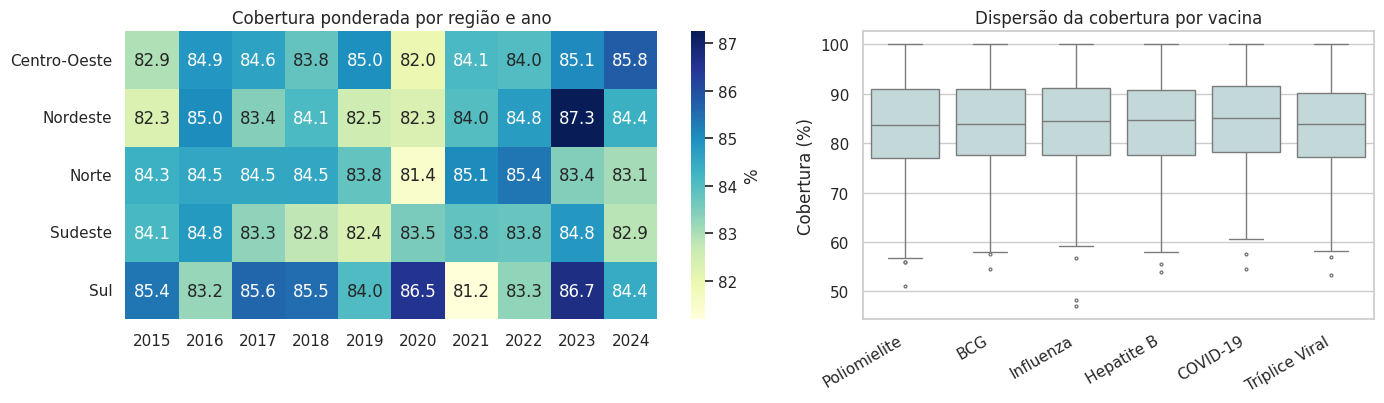

In [11]:
pivo = df.groupby(["regiao", "ano"]).apply(cobertura_ponderada).unstack()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
sns.heatmap(pivo, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "%"}, ax=ax[0])
ax[0].set(title="Cobertura ponderada por região e ano", xlabel="", ylabel="")
sns.boxplot(data=df, x="vacina", y="cobertura_percentual", color="#BFDCDB", fliersize=2, ax=ax[1])
ax[1].set(title="Dispersão da cobertura por vacina", xlabel="", ylabel="Cobertura (%)")
plt.setp(ax[1].get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); salvar("04_heatmap_regiao_ano"); plt.show()

**Interpretação.** O mapa de calor não mostra faixas persistentes: nenhuma região fica sempre acima ou abaixo das outras. Os boxplots das vacinas quase coincidem,
com medianas próximas de 84% e caixas de largura semelhante.

### 7.5 Níveis de alerta por região e geografia

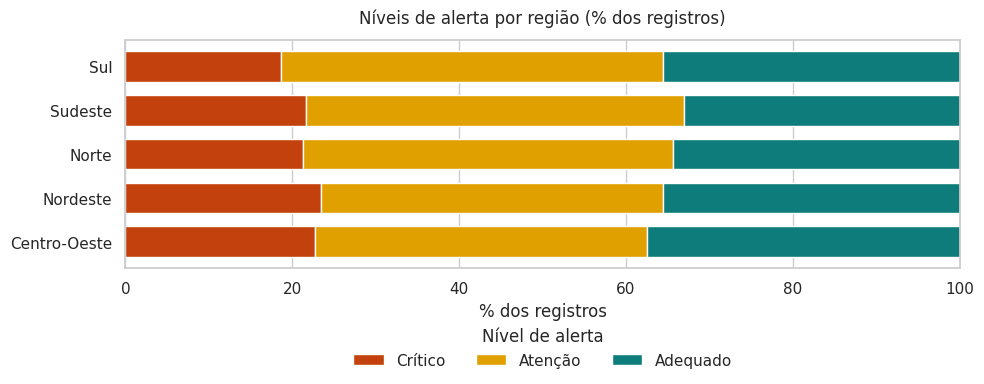

UFs com menor cobertura: {'MS': 81.97, 'RO': 83.0, 'AM': 83.06}
UFs com maior cobertura: {'BA': 84.94, 'TO': 85.26, 'GO': 85.59}


nivel_alerta,Crítico,Atenção,Adequado
regiao,,,
Centro-Oeste,22.7,39.8,37.5
Nordeste,23.4,41.0,35.5
Norte,21.3,44.3,34.3
Sudeste,21.7,45.3,33.0
Sul,18.6,45.8,35.6


In [12]:
alerta_reg = pd.crosstab(df.regiao, df.nivel_alerta, normalize="index")[["Crítico", "Atenção", "Adequado"]] * 100
ax = alerta_reg.plot(kind="barh", stacked=True, figsize=(10, 4.2), width=.7,
                     color=[COR_ALERTA[c] for c in alerta_reg.columns])
ax.set_title("Níveis de alerta por região (% dos registros)", pad=12)
ax.set(xlabel="% dos registros", ylabel="", xlim=(0, 100))
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(.5, -.2), title="Nível de alerta")
plt.tight_layout(); salvar("05_alerta_regiao"); plt.show()

uf = df.groupby("uf").apply(cobertura_ponderada).sort_values()
print("UFs com menor cobertura:", uf.head(3).round(2).to_dict())
print("UFs com maior cobertura:", uf.tail(3).round(2).to_dict())
alerta_reg.round(1)

**Interpretação.** A região **Sul** tem o menor percentual de registros críticos (18,6%) e a **Nordeste** o maior (23,4%), mas a diferença é de 4,8 p.p.
Por UF, as menores coberturas são **MS (82,0%)**, **RO (83,0%)** e **AM (83,1%)**, e as maiores, **GO (85,6%)**, **TO (85,3%)** e **BA (84,9%)**. O mapa interativo está
na página *Mapa Geográfico* do dashboard.

## 8. Correlação estatística e campanhas

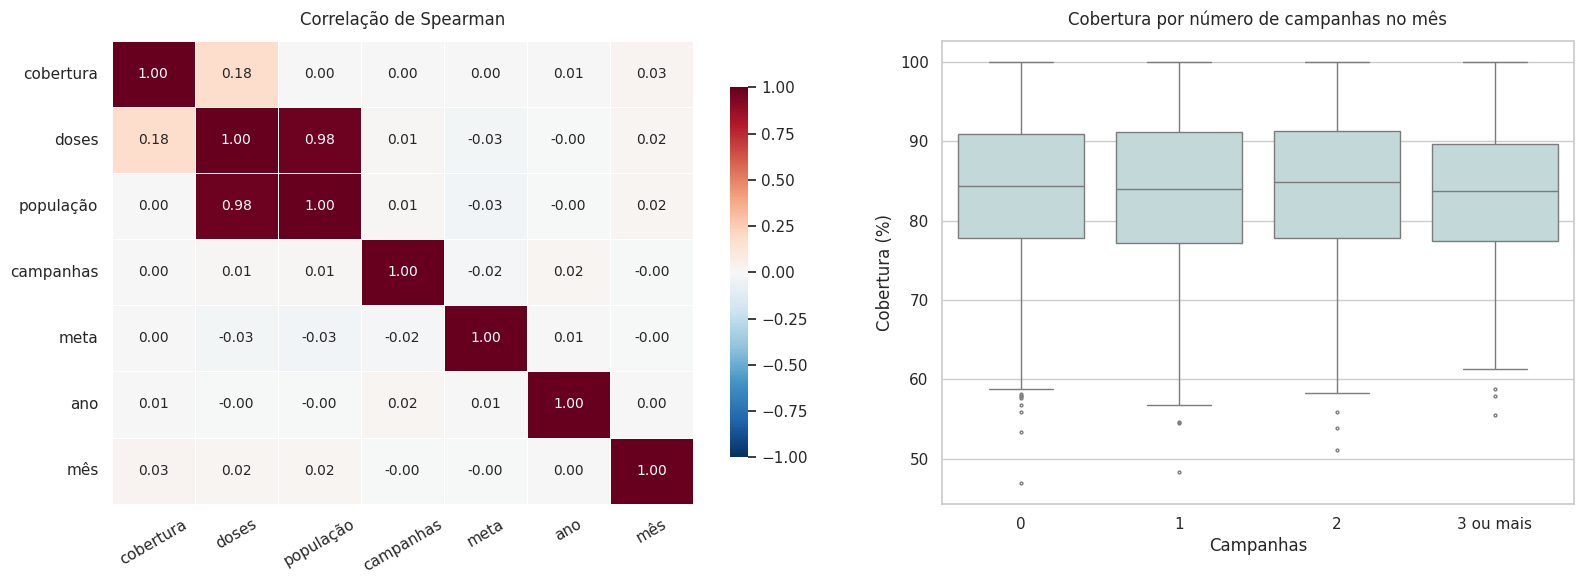

Pearson cobertura x doses: 0.2
Spearman cobertura x campanhas: 0.002


campanhas,0,1,2,3,4,5,6
registros,1622.00,1658.00,821.00,265.00,58.00,12.00,4.00
cobertura_media,83.98,83.94,84.41,83.63,83.28,83.43,73.21


In [13]:
cols = ["cobertura_percentual", "doses_aplicadas", "populacao_alvo", "campanhas", "meta_percentual", "ano", "mes"]
rotulos = ["cobertura", "doses", "população", "campanhas", "meta", "ano", "mês"]
corr = df[cols].corr(method="spearman")
corr.index = corr.columns = rotulos

fig, ax = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.15, 1]})
sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={"size": 10}, cmap="RdBu_r", vmin=-1, vmax=1,
            linewidths=.5, linecolor="white", cbar_kws={"shrink": .8}, ax=ax[0])
ax[0].set_title("Correlação de Spearman", pad=12)
ax[0].tick_params(axis="x", rotation=30); ax[0].tick_params(axis="y", rotation=0)
sns.boxplot(data=df, x="grupo_campanhas", y="cobertura_percentual", order=["0", "1", "2", "3 ou mais"],
            color="#BFDCDB", fliersize=2, ax=ax[1])
ax[1].set_title("Cobertura por número de campanhas no mês", pad=12)
ax[1].set(xlabel="Campanhas", ylabel="Cobertura (%)")
plt.tight_layout(w_pad=3); salvar("06_correlacao_campanhas"); plt.show()

print("Pearson cobertura x doses:", round(df.cobertura_percentual.corr(df.doses_aplicadas), 3))
print("Spearman cobertura x campanhas:", round(corr.loc["cobertura", "campanhas"], 3))
df.groupby("campanhas").agg(registros=("ano", "size"), cobertura_media=("cobertura_percentual", "mean")).round(2).T

**Interpretação.**
- **Doses × cobertura (0,18 em Spearman; 0,20 em Pearson):** correlação fraca. Doses e população-alvo são quase a mesma informação (0,98). É esperada em parte por construção (cobertura = doses ÷ população), e o que enfraquece o valor é a população-alvo variar muito entre registros.
- **População-alvo × cobertura (≈ 0):** municípios com públicos maiores não têm cobertura maior.
- **Campanhas × cobertura (≈ 0,00):** a cobertura média é de cerca de 84% com 0, 1 ou 2 campanhas. Com 6 campanhas a média cai para 73,2%, mas são **apenas 4 registros**,
  número pequeno demais para concluir algo.
- **Ano e mês × cobertura (≈ 0):** confirmam a ausência de tendência e de sazonalidade forte.

Lembrete: correlação não prova causalidade. A ausência de correlação aqui significa que, **nesta base**, mais campanhas não vieram acompanhadas de mais cobertura.

## 9. Conclusão
1. **Cobertura média de 84,0%, abaixo da meta.** Só 34,8% dos registros atingem a meta e 21,6% estão em nível crítico; a distância média da meta é de 5,1 p.p.
   Boa parte vem de metas de 95%, presentes em 60,8% dos registros.
2. **Estabilidade no tempo.** De 2015 a 2024 a cobertura anual fica entre 83,2% e 85,5%, sem tendência (+0,04 p.p./ano).
3. **Problema distribuído.** Vacinas, regiões, UFs e públicos-alvo diferem em cerca de 1 p.p. na média (entre UFs, até 3,6 p.p.), então não há um
   recorte único para concentrar esforços. A variação importante está **dentro** de cada grupo, entre municípios e meses.
4. **Campanhas não explicam a cobertura nesta base.** Correlação praticamente nula; o efeito das campanhas precisa ser medido com dados mais detalhados (por exemplo, antes e depois de cada campanha).
5. **Limitações.** Os dados são simulados; a cobertura é derivada das doses e da população; o `nivel_alerta` é função direta da meta; e há apenas 37 municípios.
   Os resultados ilustram o método e não devem orientar decisões reais.

**Próximos passos:** testar a significância das diferenças entre grupos (ANOVA ou Kruskal-Wallis), analisar quais municípios ficam críticos de forma recorrente e,
com dados reais do PNI/DATASUS, repetir a análise.